# Entraînement supervisé

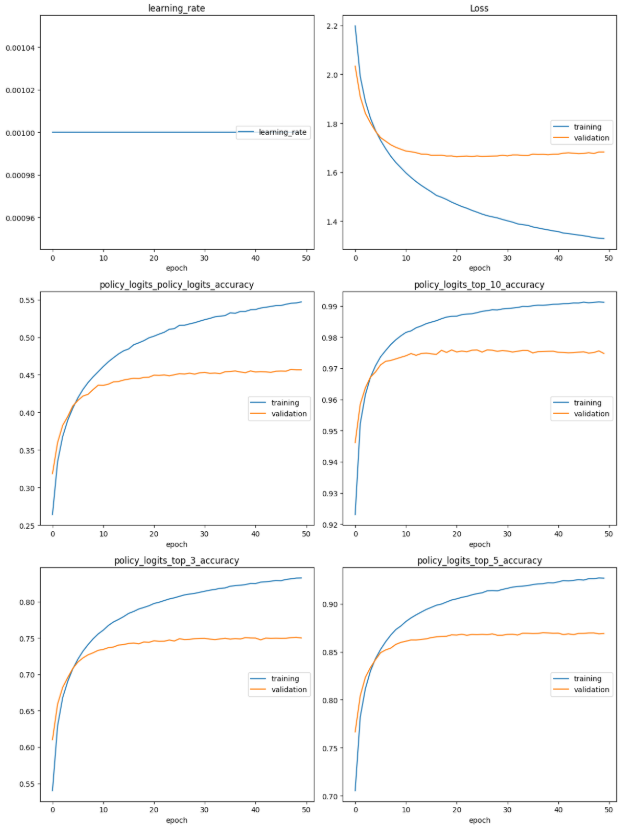

# Entraînement de la tête de valeur

PRETRAINED_WEIGHTS = '../saved-models/DensePlayer-v7-best.weights.h5'
SAVE_PATH         = '../saved-models/Tairanauchu2-value-head-pretrain'

N_ITERATIONS  = 100   # Nombre d'itérations collect + update
N_GAMES       = 128    # Parties par itération
N_EPOCHS      = 4     # Passes sur les données collectées
MINIBATCH_SIZE = 64
LEARNING_RATE = 3e-4  
# lam=1.0 + gamma=1.0 : returns = outcome final pur (±1), sans bootstrap sur V(s)
GAMMA = 1.0
LAM   = 1.0

SAVE_EVERY = 20
PLOT_EVERY = 1

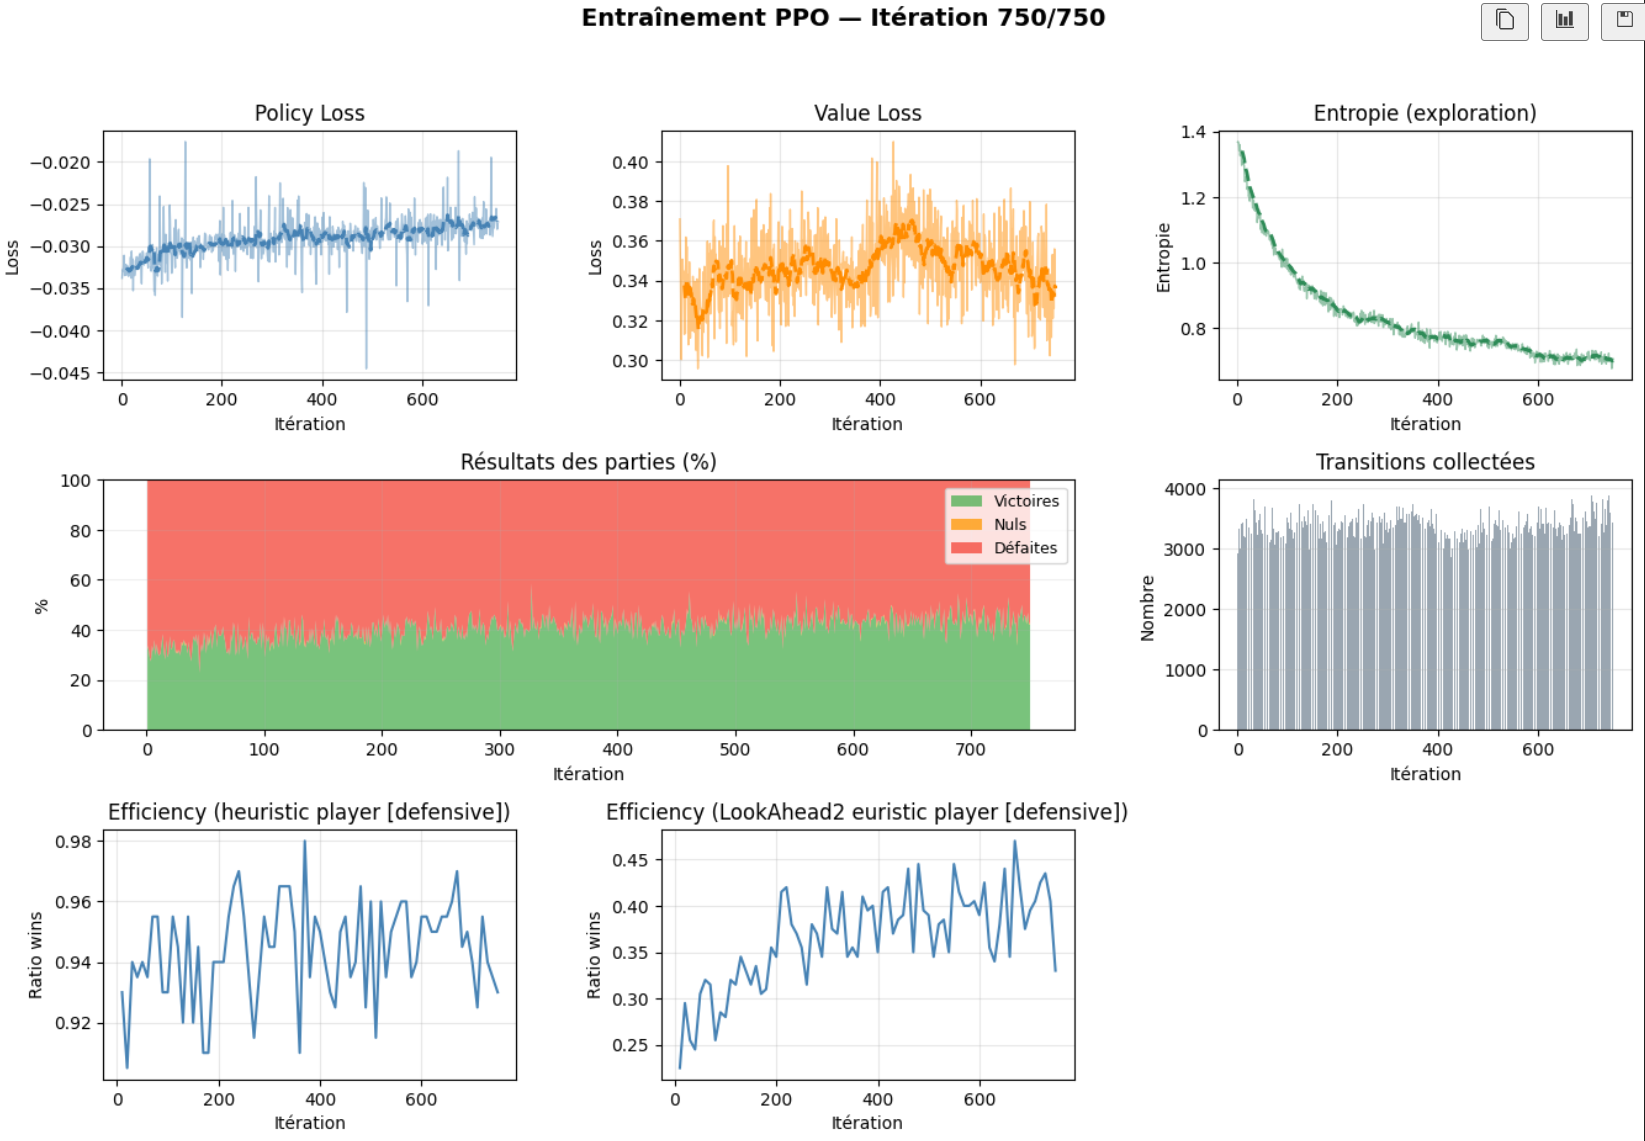

# Entraînement PPO

PRETRAINED_WEIGHTS = '../saved-models/Tairanauchu1.weights.h5'
SAVE_PATH = '../saved-models/ppo-tairanauchu3-e1'

N_ITERATIONS = 750
N_GAMES = 128
N_EPOCHS = 4
MINIBATCH_SIZE = 64
LEARNING_RATE = 1e-4
CLIP_EPSILON = 0.1
VALUE_COEF = 0.5
ENTROPY_COEF = 0.01
GAMMA = 0.99
LAM = 0.95
SAVE_EVERY = 10

# Fréquence de mise à jour des graphiques (toutes les N itérations)
PLOT_EVERY = 1

#Fréquence de réalisation d'un test d'efficience du réseau
EFFICIENCY_EVERY = 10
EFFICIENCY_NB_GAMES = 200

p1 = DensePlayer_v7()
p1.load_weights(PRETRAINED_WEIGHTS)
p2 = DensePlayer_v7()

p2_alt1 = LookAheadHeuristicPlayer(max_depth=2, heuristic_function="heuristic_defensive")
p2_alt2 = LookAheadHeuristicPlayer(max_depth=1, heuristic_function="heuristic_defensive")
p2_alt3 = LookAheadHeuristicPlayer(max_depth=3, heuristic_function="heuristic_aggressive")

trainer = PPOTrainer(
    player1=p1,
    player2=p2,
    n_games=N_GAMES,
    n_epochs=N_EPOCHS,
    minibatch_size=MINIBATCH_SIZE,
    learning_rate=LEARNING_RATE,
    clip_epsilon=CLIP_EPSILON,
    value_coef=VALUE_COEF,
    entropy_coef=ENTROPY_COEF,
    gamma=GAMMA,
    lam=LAM,
    alternative_players=[p2_alt1, p2_alt2, p2_alt3],
    alternative_players_ratio=[30, 20, 10]
)

print("Modèle et trainer initialisés.")

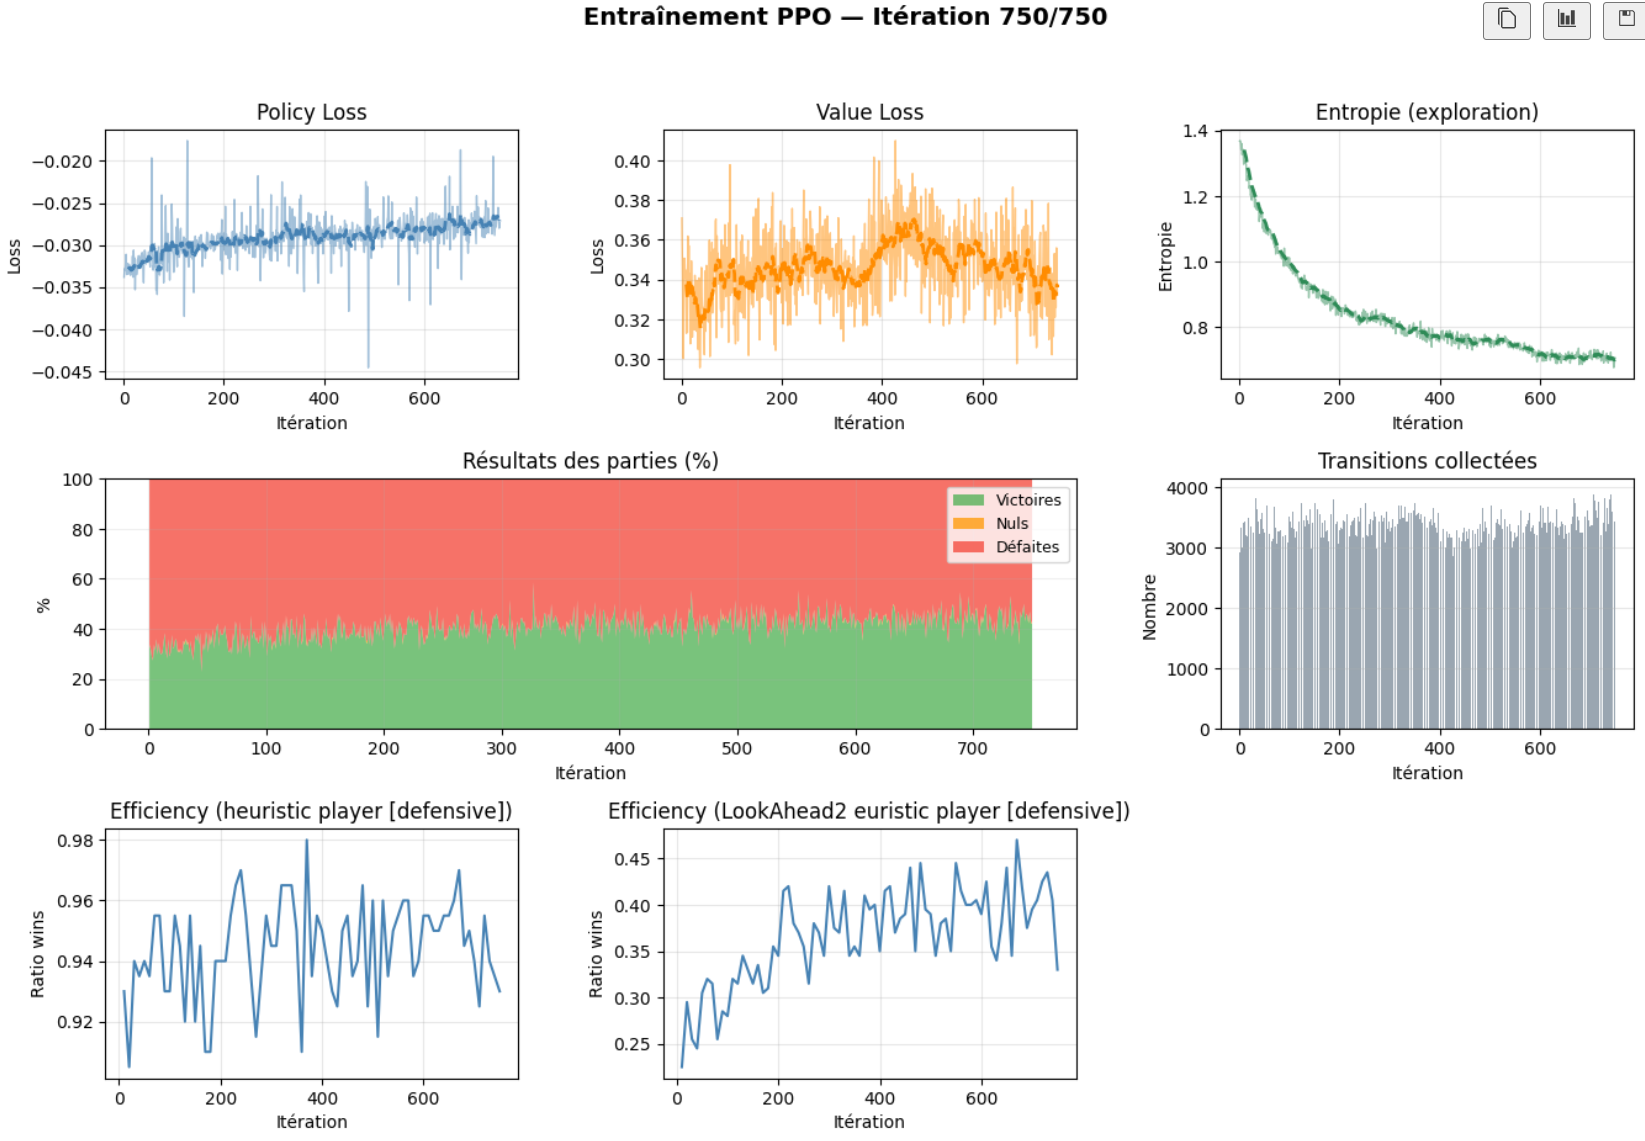